# Lecture 5: Causal Mediation Analysis

Last lecture, we looked at how intervening on a neural network's internal computation can help us remove information from it, control its behavior, and - most relevant for us - understand its internal processes. In this lecture, we will introduce the concept of **causal mediation analysis**, which applies **interchange interventions** to identify causally relevant activations and trace the information flow within the model.

### ✍ Learning goals

By the end of the lesson, we hope you feel familiar with the following concept.

* **Causal mediation analysis**: intervening on each model component to measure its causal effect on model output.
* **Tracing information flow**: how to read and interpret plots that trace the flow of information in the model when processing a specific input.
* **Entity binding**: an initial glimpse into how models track state and compute relations between two entities in context.
* **Composition of interventions**: how applying interventions form multiple sources can help us identify more fine-grained concepts in the model's activations.

## 0️⃣ Setup

Run this code to get started!

In [1]:
from IPython.display import clear_output
import plotly.io as pio

try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    pio.renderers.default = "colab"
    !git clone https://github.com/cs221m/cs221m-course.git
    %cd cs221m-course
    !pip install -r requirements/06_causal_mediation_analysis.txt
else:
    pio.renderers.default = "plotly_mimetype+png"
    !plotly_get_chrome -y

clear_output()

We'll be using a fairly small open-source model for this lecture. Just like the previous lectures, we'll use the [`nnsight` library](https://nnsight.net/) to access the internal computations of the model.

In [2]:
from nnsight import LanguageModel

model = LanguageModel("HuggingFaceTB/SmolLM2-360M")

# (use a sample prompt to load the model)
prompt = 'A Transformer is' 
with model.generate(prompt) as tracer:
  output = model.generator.output.save()

# move the model to GPU
model.to('cuda')

clear_output()

## 1️⃣ Revisiting probing

### Back to logit lens

Causal mediation analysis helps us trace the information flow in a model by identifying causally relevant parts of the model's computation. Before we get there, let's start by revisiting a **correlational** method for tracing the information flow in a model.

Logit lens works by taking the model's final unembedding layer, and applying it on the outputs of intermediate layers as an attempt to decode the information they store.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_04_probes/logit_lens.png" width="600" alt="logit lens"/>

Let's try it on a small factual recall example, and try to trace where the model stores the fact that the Eiffel Tower is in France.

In [3]:
prompt = "Eiffel Tower is in the country of"

# pass the prompt in and generate 1 new token
with model.generate(prompt, max_new_tokens=1) as tracer:
  output = model.generator.output.save()

clear_output()

print(model.tokenizer.decode(output)[0])

Eiffel Tower is in the country of France


... and that the Tokyo Tower is in Japan.

In [4]:
prompt= "Tokyo Tower is in the country of"

with model.generate(prompt, max_new_tokens=1) as tracer:
  output = model.generator.output.save()

clear_output()

print(model.tokenizer.decode(output)[0])

Tokyo Tower is in the country of Japan


How does the model correctly answer these questions? Let's first look at internals for each prompt using Logit Lens.

In [5]:
import torch

prompt= "Eiffel Tower is in the country of"

layer_range = list(range(20, len(model.model.layers))) # start from layer 10 to save time

decoded_layers = []
with model.trace(prompt):
    for layer_index in layer_range:
        # get layer activation
        layer_activation = model.model.layers[layer_index].output
        layer_activation = model.model.norm(layer_activation)
        # pass the layer through the final LM head to predict next token
        decoded_layer_logits = model.lm_head(layer_activation)
        # apply softmax to get a probability distribution over the next token
        decoded_layer = torch.nn.functional.softmax(decoded_layer_logits, dim=-1)
        decoded_layers.append(decoded_layer.save())

decoded_layers = torch.cat(decoded_layers) # (num_layers, num_tokens, vocab_size)

# find the maximum probability and corresponding tokens for each position
probabilities, decoded_tokens = decoded_layers.max(dim=-1)

# decode token ids
decoded_tokens = [
    [model.tokenizer.decode(t.item()) for t in layer_tokens]
    for layer_tokens in decoded_tokens
]

Let's visualize the information decoded for each of our prompts below.

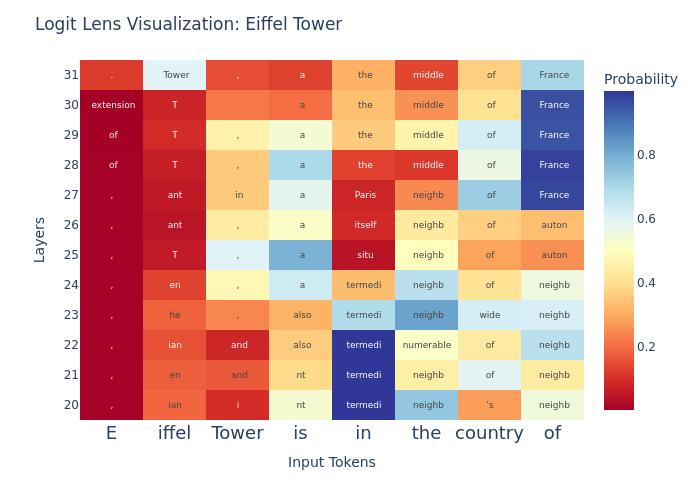

In [6]:
import plotly.express as px

input_tokens = [t.replace('Ġ', '') for t in model.tokenizer.tokenize(prompt)]

fig = px.imshow(
    probabilities.detach().cpu().float().numpy(),
    x=input_tokens,
    y=layer_range,
    origin="lower", # make 0 at the bottom
    color_continuous_scale=px.colors.diverging.RdYlBu,
    color_continuous_midpoint=0.50,
    text_auto=True,
    labels=dict(x="Input Tokens", y="Layers", color="Probability")
)

fig.update_layout(
    title='Logit Lens Visualization: Eiffel Tower',
    xaxis_tickangle=0
)

fig.update_xaxes(tickfont_size=18) 
fig.update_yaxes(tickvals=layer_range)
fig.update_traces(text=decoded_tokens, texttemplate="%{text}")

fig.show()

Looks like the final answer, "France", pops up at layer 27 (curiously, it's also around the same time that "Paris" pops up above "in"!). Is "Japan" recalled from "Tokyo Tower" around a similar time for our other prompt?

### Logit lens on a minimal pair

Let's run the same logit lens analysis, but this time on "Tokyo Tower" instead of "Eiffel Tower". Is the information processed in the same way?

In [7]:
prompt= "Tokyo Tower is in the country of"

layer_range = list(range(20, len(model.model.layers))) # start from layer 10 to save time

decoded_layers = []
with model.trace(prompt):
    for layer_index in layer_range:
        # get layer activation
        layer_activation = model.model.layers[layer_index].output
        layer_activation = model.model.norm(layer_activation)
        # pass the layer through the final LM head to predict next token
        decoded_layer_logits = model.lm_head(layer_activation)
        # apply softmax to get a probability distribution over the next token
        decoded_layer = torch.nn.functional.softmax(decoded_layer_logits, dim=-1)
        decoded_layers.append(decoded_layer.save())

decoded_layers = torch.cat(decoded_layers) # (num_layers, num_tokens, vocab_size)

# find the maximum probability and corresponding tokens for each position
probabilities, decoded_tokens = decoded_layers.max(dim=-1)

# decode token ids
decoded_tokens = [
    [model.tokenizer.decode(t.item()) for t in layer_tokens]
    for layer_tokens in decoded_tokens
]

input_tokens = [t.replace('Ġ', '') for t in model.tokenizer.tokenize(prompt)]

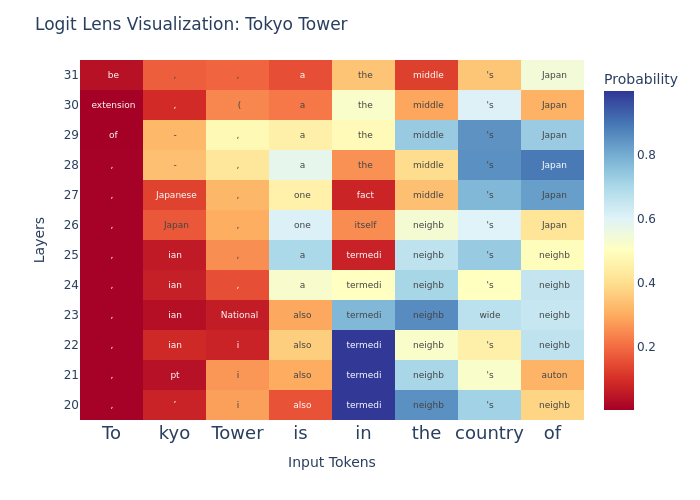

In [8]:
pio.renderers.default = "colab" if is_colab else "notebook_connected+plotly_mimetype+png"

fig = px.imshow(
    probabilities.detach().cpu().float().numpy(),
    x=input_tokens,
    y=layer_range,
    origin="lower", # make 0 at the bottom
    color_continuous_scale=px.colors.diverging.RdYlBu,
    color_continuous_midpoint=0.50,
    text_auto=True,
    labels=dict(x="Input Tokens", y="Layers", color="Probability")
)

fig.update_layout(
    title='Logit Lens Visualization: Tokyo Tower',
    xaxis_tickangle=0
)

fig.update_xaxes(tickfont_size=18) 
fig.update_yaxes(tickvals=layer_range)
fig.update_traces(text=decoded_tokens, texttemplate="%{text}")

fig.show()

We can see that the **country** representation emerges at around layer 26-27 in both cases. This suggests that the layer representations in these layers are driving the correct model prediction. But as we saw last lesson, just because we can **decode** the information at that layer, it doesn't mean that this it plays a **causal role** in producing the model's final output.

To find out **how** these country representations are calculated inside the model, we want to draw a computaitonal graph showing how the difference in the prompt ("Eiffel" vs "Tokyo") gets transformed into difference in the prediction ("France" vs "Japan"). As we'll see in the next section, <b>causal mediation analysis</b> helps us address this problem by quantifying the contribution of each model component on the output behavior.

## 2️⃣ Causal Mediation Analysis

### Formalizing causal mediation

Let's formally characterize this model behavior. We know that the model correctly predicts "France" instead of "Japan" as a continuation of the phrase "Eiffel Tower is in the country of". This can be descirbed as 


$$p(\text{France} \mid c_E) > p(\text{Japan} \mid c_E)$$

Here we used $c_{E}$ to denote the phrase "Eiffel Tower is in the country of".

We can quantify the model confidence by the difference in log probability (log odds).

$$\text{LogOdds}(\text{France},\text{Japan} \mid c_E) := \log p(\text{France} \mid c_E) - \log p(\text{Japan} \mid c_E)$$

Using this metric, the fact that the model correctly predicts "France" after "Eiffel Tower is in the country of" can be written as 

$$\text{LogOdds}(\text{France},\text{Japan} \mid c_E)>0$$

Similarly, the fact that the model correctly predicts "Japan" after "Tokyo Tower is in the country of" can be written as 

$$\text{LogOdds}(\text{France},\text{Japan} \mid c_T) < 0$$

where $c_{T}$ refers to the phrase "Tokyo Tower is in the country of."

Our goal, then, is to understand how the model flips the sign of the log odds depending on the context ($c_E$ vs $c_T$).Specifically, we want to clarify how each model component is involved in this change in log odds. To do this, we perform interchange intervention on the intermediate model representations and measure its effect on the log odds.

Let's say we want to see how much the last layer (32nd layer) representation at the last token ("of") influences the model prediction. We quantify this effect as follows:

$$\text{LogOdds}(\text{France},\text{Japan} \mid c_E)-\text{LogOdds}(\text{France},\text{Japan} \mid c_E,h^{\text{last},32}_E←h^{\text{last},32}_T)$$

Here $h^{\text{last},32}_E$ refers to the 32nd layer representation at the last token in the "Eiffel Tower" context ($c_E$), whereas $h^{\text{last},32}_T$ refers to the 32nd layer representation at the last token in the "Tokyo Tower" context ($c_T$).

$\text{LogOdds}(\text{France},\text{Japan}|c_E,h^{\text{last},32}_E←h^{\text{last},32}_T)$ is the log odds after the model intervention. To calculate this, we start with the 'Eiffel Tower' context, but use the last layer representation of the last token from the 'Tokyo Tower' context ($h^{\text{last},\,32}_T$) and run the rest of the model to get the log probabilities. In other words, this metric quantifies how much the model changes the prediction (measured by the log odds) based on the intervention.

### Tracing information flow with causal mediation analysis

We can repeat this for each layer and each token position to track how the model component in each layer at each token position influences the model prediction.

In [9]:
base_prompt = "Eiffel Tower is in the country of"
source_prompt = "Tokyo Tower is in the country of"

In [10]:
base_next_word = "France"
source_next_word = "Japan"

In [11]:
base_output = model.tokenizer(" " + base_next_word.strip())["input_ids"][0] # includes a space
source_output = model.tokenizer(" " + source_next_word.strip())["input_ids"][0] # includes a space

In [12]:
# calculate the original log odds
with model.trace(base_prompt) as tracer:
    original_logits = model.output.logits[:, -1, :].save()

clear_output()

original_logprobs = original_logits.log_softmax(dim=-1)
original_logodds = (original_logprobs[0, base_output] - original_logprobs[0, source_output]).item()

In [13]:
# collect source activations
source_hidden_states = []
with torch.no_grad():
    with model.trace(source_prompt):
        # get hidden states of all layers in the network
        source_hidden_states.append([
            layer.output.save()
            for layer in model.model.layers
        ])
source_hidden_states = source_hidden_states[0]

In [14]:
# intervene and collect intervention results
token_idx_list = [[0,1],[2],[3],[4],[5],[6],[7]] # concatenate the two tokens corresponding to Eiffel and Tokyo

causal_effects = []
# iterate through all the layers
for layer_idx in range(model.config.num_hidden_layers):
    causal_effect_per_layer = []
    # iterate through all tokens
    for token_idx in token_idx_list:
        with torch.no_grad():
            with model.trace(base_prompt) as tracer:
                # change the value of the base activation to the source value
                model.model.layers[layer_idx].output[:, token_idx, :] = \
                    source_hidden_states[layer_idx][:, token_idx, :]

                # get intervened output
                intervened_logits = model.output.logits[:, -1, :]
                intervened_logprobs = intervened_logits.log_softmax(dim=-1)
                # calcualte the log odds with intervention
                intervened_logodds = (intervened_logprobs[0, base_output] - intervened_logprobs[0, source_output]).item()
                effect = (original_logodds - intervened_logodds).save()

            causal_effect_per_layer.append(effect)
    causal_effects.append(causal_effect_per_layer)

In [15]:
# get the labels for the plot
base_tokens = [model.tokenizer.decode([token]).strip() for token in model.tokenizer(base_prompt+' '+base_next_word).input_ids]
source_tokens = [model.tokenizer.decode([token]).strip() for token in model.tokenizer(source_prompt+' '+source_next_word).input_ids]

# show the intervention we're performing
label_tokens = [''.join([base_tokens[i] for i in tokens])+ '<br>↑<br>' +''.join([source_tokens[i] for i in tokens]) for tokens in token_idx_list]

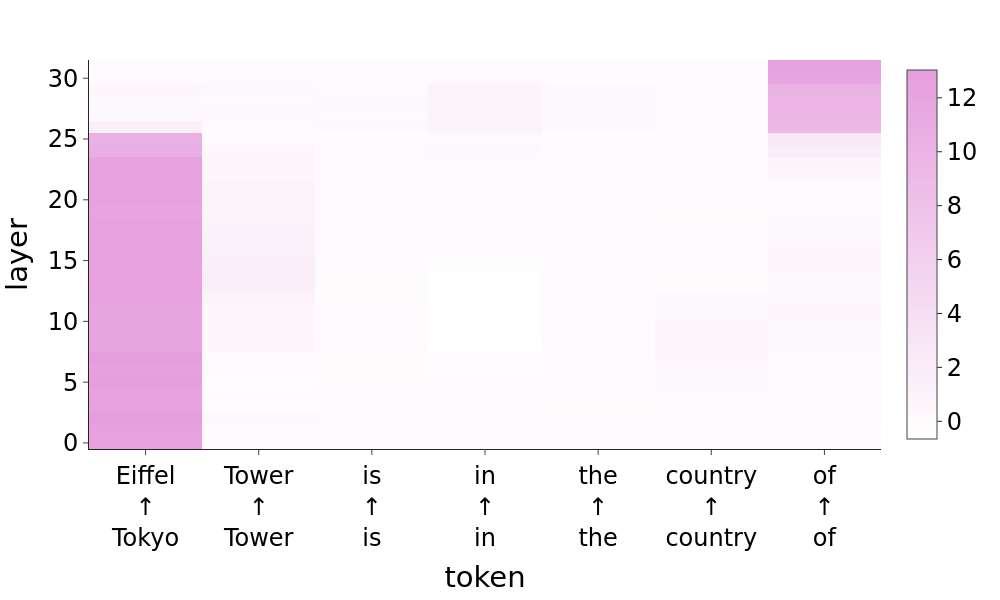

In [16]:
# visualize our results!
fig = px.imshow(
    causal_effects,
    x=label_tokens,
    y=list(range(model.config.num_hidden_layers)),
    template='simple_white',
    color_continuous_scale=[[0, '#FFFFFF'], [1, "#E59EDD"]]
)

fig.update_layout(
    xaxis_title='token',
    yaxis_title='layer',
    yaxis=dict(autorange='min'),
    font=dict(
        family="Arial, sans-serif",
        size=24,  # Global font size
        color="black"
    ),
    height=600,
    width=1000
)

fig.show()

Let's interpret this result!
1. First, we see that not all model components influence the model predictions; in fact, the ones that actually drive the model predictions are localized to specific token positions.
2. Second, there is a specific layer (**layer 26**) where the 'information' (whether the prompt is 'Eiffel Tower' context or 'Tokyo Tower' context) moves from 'Eiffel/Tokyo' to the last token of the prompt.
3. This is consistent with the result from Logit Lens!

It's worth noting that **no matter what**, we'll always see the following things:

* **At the first layer**, only the information we **change** will make a difference (e.g., Tokyo -> Eiffel), since the model doesn't have the time to integrate any other information into its computation yet.
* **At the last layer**, the very final token will **always** have a causal effect, since the next token prediction comes directly from there.
* Putting these two things together, it means that the model always has to find a way to **move information** from what we changed at the first layer to the very final token at the very last layer!

### ✏ **Exercise 1**

The experiment above tests how the model translates the difference in the monument entities (the Eiffel Tower vs Tokyo Tower) into the difference in the countries they are in (France vs Japan). We may also be interested in is how the model knows which property of the monument entity it should focus on. For example, how does the model answer which <b>country</b> the Eiffel Tower is in, and not which <b>city</b>? How can we investigate this aspect of model behavior?

Use the same base prompt and change the source prompt to answer this question! This time, we should isolate whether we're asking about the **country** or the **city** that the Eiffel Tower is in.

*Hint: we don't need Tokyo Tower anymore; instead, what's the minimal change we should make to the prompt below to find out which city the Eiffel Tower is in?*

In [17]:
base_prompt = "Eiffel Tower is in the country of"
source_prompt = "" # YOUR SOURCE PROMPT

In [18]:
base_next_word = "France"
source_next_word = "" # NEXT TOKEN FOR SOURCE PROMPT

In [19]:
base_output = model.tokenizer(" "+base_next_word.strip())["input_ids"][0] # includes a space
source_output = model.tokenizer(" "+source_next_word.strip())["input_ids"][0] # includes a space

In [20]:
# calculate the original log odds

In [21]:
# collect source activations

In [22]:
# intervene and collect intervention results

In [23]:
# get the labels for the plot

In [24]:
# visualize our results!

At what layer does the information **move** from the token we changed (country vs. city) to the final token in the model? Does it correspond to either the logit lens analysis or the Eiffel vs. Tokyo minimal pair we tried previously? Why (or why not) do you think this would be the case?

> FILL IN YOUR ANSWER HERE

## 3️⃣ Exploring other types of model components

### Moving information between tokens

In the previous section, we saw that we can track the information flow across layers by measuring how much swapping each layer between the two contexts changes the model prediction (log odds). The result showed that layers before layer 26 encode the information at the token corresponding to the building, while the subsequent layers encode information at the last token of the prompt.

This means that the information is somehow **transported** from the building token to the last token at around layer 26. We know that this **had to be done** by an attention component, since only attention can **move information** from one token to another within the model. But which attention head (e.g., what layer and what head) was responsible for moving this particular concept about the Eiffel Tower?

To investigate this question, we will intervene on the attention output and see how the intervention affects model prediciton.

In [25]:
base_prompt = "Eiffel Tower is in the country of"
source_prompt = "Tokyo Tower is in the country of"

In [26]:
base_next_word = "France"
source_next_word = "Japan"

In [27]:
base_output = model.tokenizer(" "+base_next_word.strip())["input_ids"][0] # includes a space
source_output = model.tokenizer(" "+source_next_word.strip())["input_ids"][0] # includes a space

In [28]:
# calculate the original log odds
with model.trace(base_prompt) as tracer:
    original_logits = model.output.logits[:, -1, :].save()

clear_output()

original_logprobs = original_logits.log_softmax(dim=-1)
original_logodds = (original_logprobs[0, base_output] - original_logprobs[0, source_output]).item()

In [29]:
# collect source activations
source_hidden_states = []
with torch.no_grad():
    with model.trace(source_prompt):
        # index into attention head outputs
        source_hidden_states.append([
            layer.self_attn.o_proj.input.save()
            for layer in model.model.layers
        ])
source_hidden_states = source_hidden_states[0]

In [30]:
# intervene and collect intervention results
attn_dim = model.config.hidden_size // model.config.num_attention_heads # dimension of each head

causal_effects = []
# iterate through layers (24-32) to save time
for layer_idx in range(24,32):
    causal_effect_per_layer = []
    # iterate through all tokens
    for head_index in range(model.config.num_attention_heads):
        with torch.no_grad():
            with model.trace(base_prompt) as tracer:
                # change the value of the base activation to the source value
                attention_value = model.model.layers[layer_idx].self_attn.o_proj.input
                # change value only at attention head index of the last token
                attention_value[:, -1, head_index * attn_dim:(head_index + 1) * attn_dim] = \
                source_hidden_states[layer_idx][:, -1, head_index * attn_dim:(head_index + 1) * attn_dim]
                # put attention head back in
                model.model.layers[layer_idx].self_attn.o_proj.input = attention_value

                # get intervened output
                intervened_logits = model.output.logits[:, -1, :]
                intervened_logprobs = intervened_logits.log_softmax(dim=-1)
                # calcualte the log odds with intervention
                intervened_logodds = (intervened_logprobs[0, base_output] - intervened_logprobs[0, source_output]).item()
                effect = (original_logodds - intervened_logodds).save()

            causal_effect_per_layer.append(effect)
    causal_effects.append(causal_effect_per_layer)

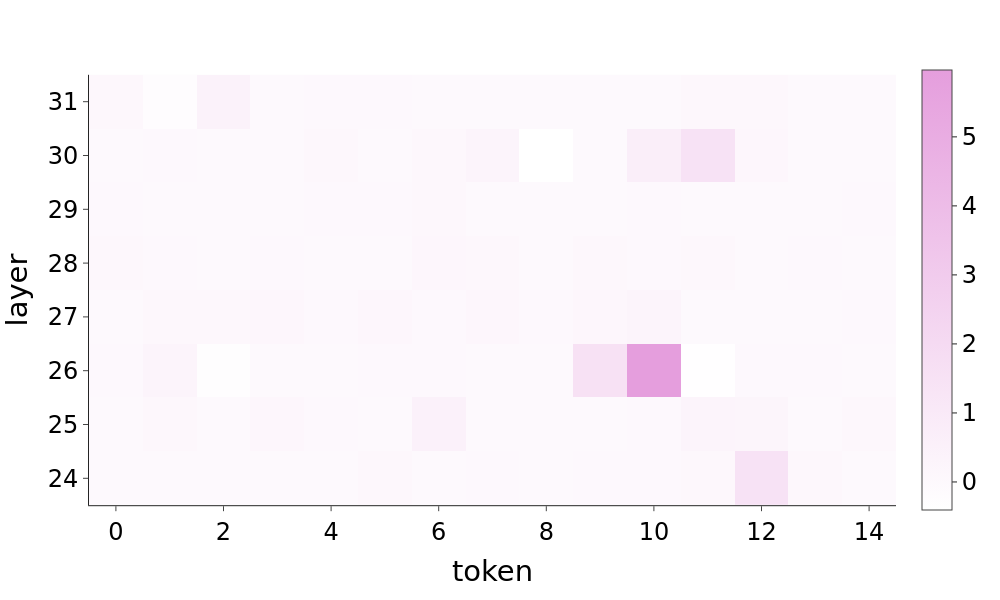

In [31]:
# visualize our results!
fig = px.imshow(
    causal_effects,
    x=list(range(model.config.num_attention_heads)),
    y=list(range(24,32)),
    template='simple_white',
    color_continuous_scale=[[0, '#FFFFFF'], [1, "#E59EDD"]]
)

fig.update_layout(
    xaxis_title='token',
    yaxis_title='layer',
    yaxis=dict(autorange='min'),
    font=dict(
        family="Arial, sans-serif",
        size=24,  # Global font size
        color="black"
    ),
    height=600,
    width=1000
)

fig.show()

Let's unpack this result! As expected from the result in the previous section, we observe a large effect in layer 26. Interestingly, we see this effect only for a **specific attention head** (head 10) and not others. This means attention head 10 in layer 26 transfers context information ($c_E$ vs $c_T$) from the building tokens to the last token in the prompt.

Turns out, this is often the case! For a given input (or set of inputs that form a specific task, like say one-digit multiplication), very few components in the model do a vast majority of the work. Why do you think that might be?

### Visualizing attention pattern

Let's go all the way back to what we did on the first lecture, and visualize the attention pattern for the head that we think is responsible for moving information from "Eiffel Tower" to the final token of the input "in". What would we expect the attention pattern to look like?

In [32]:
# get the attention output at layer 26
model.config._attn_implementation = "eager"
prompt = "The Eiffel Tower is in"

with model.trace(prompt):
  outputs = model.model.layers[26].self_attn.source.attention_interface_0.output.save()

attn_outputs, attn_weights = outputs

attn_weights.shape

torch.Size([1, 15, 6, 6])

Let's visualize the attention pattern at layer 26, head #10 (the model has 14 attention heads working in parallel!).

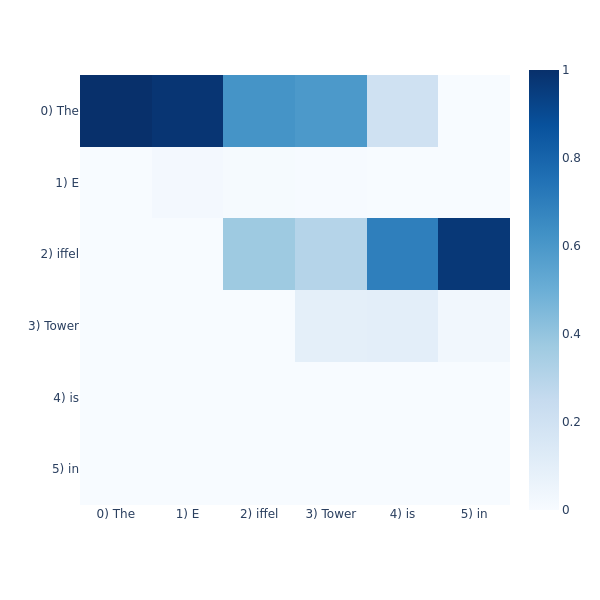

In [33]:
import plotly.express as px

tokens =[t.replace('Ġ', '') for t in model.tokenizer.tokenize(prompt)]

fig = px.imshow(
    # look at attention head #3
    attn_weights[0, 10].detach().cpu().float().T,
    x=[f"{i}) {l}" for i, l in enumerate(tokens)],
    y=[f"{i}) {l}" for i, l in enumerate(tokens)],
    width=600,
    height=600,
    color_continuous_scale="Blues"
)

fig.show()

The main column we want to focus on is above the "in" token. Indeed, attention head #10 attends to nearly **all of "Eiffel"** above the "in" token! We can quickly confirm that this isn't the case for other attention heads by visualizing their attention patterns. For instance, let's look at attention head #11 instead of #10 at the same layer (26).  

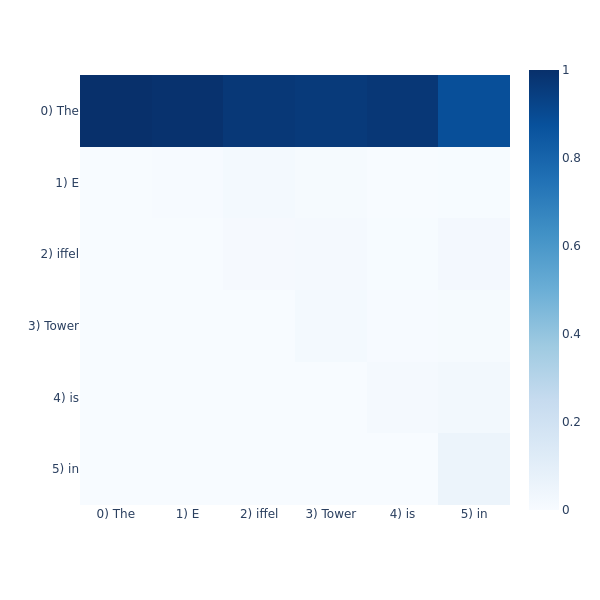

In [34]:
# visualizing a different attention head!
import plotly.express as px

tokens =[t.replace('Ġ', '') for t in model.tokenizer.tokenize(prompt)]

fig = px.imshow(
    # look at attention head #3
    attn_weights[0, 11].detach().cpu().float().T,
    x=[f"{i}) {l}" for i, l in enumerate(tokens)],
    y=[f"{i}) {l}" for i, l in enumerate(tokens)],
    width=600,
    height=600,
    color_continuous_scale="Blues"
)

fig.show()

### ✏ **Exercise 2**

Just as in Exercise 1, let's do the same analysis, but this time understanding where the model represents different attributes of the same city - specifically, how does it know to choose the country and not, say, the city that the Eiffel Tower is in?

To complete the exercise, follow the code we produced above but with new pair of base and source pairs. What should they be?

*Hint: you can re-use the same base & source from Exercise 1!*

In [35]:
base_prompt = "Eiffel Tower is in the country of"
source_prompt = "" # YOUR SOURCE PROMPT

In [36]:
base_next_word = "France"
source_next_word = "" # NEXT TOKEN FOR SOURCE PROMPT

In [37]:
base_output = model.tokenizer(" "+base_next_word.strip())["input_ids"][0] # includes a space
source_output = model.tokenizer(" "+source_next_word.strip())["input_ids"][0] # includes a space

In [38]:
# calculate the original log odds

In [39]:
# collect source activations

In [40]:
# intervene and collect intervention results

In [41]:
# visualize our results!

Which attention head is responsible for moving the appropriate attribute (country vs. city) from the Eiffel Tower token? Does it correspond to the same attention head we identified using the Eiffel vs. Tokyo minimal pair? Why (or why not) would this be the case?

> FILL IN YOUR ANSWER HERE

## 4️⃣ Tracking states

### Working memory in neural networks

In the previous section, we saw how causal mediation analysis can help us track the flow of information in the model as it makes a specific computation (e.g., recalling the country that the Eiffel Tower is in). With this method, we identified the causally relevant activations for the computation, and left with the following takeaways:

1. The information starts at the tokens we changed (had to be the case!),
2. The information ends at the last token before the output (again, had to be the case!),
3. There's a **single attention head** that moves this information from the "Eiffel" token to the final token of the prompt (pretty surprising!).

Interestingly, the model didn't store any intermediate information about the Eiffel Tower anywhere else - it only needed the activation over "Eiffel" and "in" to successfully recall the location of the Eiffel Tower. Is this always the case? In this section, we'll investigate the "working memory" of language models - or how they **track state** across a longer prompt - through causal mediation analysis!

Let's describe a scenario, and see which activations are causally responsible for updating the model's world model. We'll do this by making a minimal edit to the scenario that changes something about the world we describe - in this case, we'll change whether Alice's cup is cold (because it's in the fridge) or empty (because she drank it).

In [42]:
base_prompt = "Alice poured coffee into a cup. Then, she put it in the fridge. Now, the cup is"

with torch.no_grad(): # disable gradient for faster compute
    with model.generate(base_prompt, max_new_tokens=1) as tracer:
      output = model.generator.output.save()

clear_output()

print(model.tokenizer.decode(output)[0])

Alice poured coffee into a cup. Then, she put it in the fridge. Now, the cup is cold


In [43]:
source_prompt =  "Alice poured coffee into a cup. Then, she drank it in one go. Now, the cup is"

with torch.no_grad():
    with model.generate(source_prompt, max_new_tokens=1) as tracer:
      output = model.generator.output.save()

clear_output()
  
print(model.tokenizer.decode(output)[0])

Alice poured coffee into a cup. Then, she drank it in one go. Now, the cup is empty


Answering these prompts require tracking the state of the cup across sentences. Namely, we expect the cup is hot & full after Alice pours the coffee into it, while we expect it will be cold once it is in the fridge, or empty once she drinks it. How does the model track these different states of the cup?

We can investigate this using Causal Mediation Analysis! Here, to save time, we will intervene on multiple tokens simultaneously. Our code will work the same way as before - the only thing that changes is how we group the tokens.

In [44]:
base_output = model.tokenizer(" cold")["input_ids"][0] # includes a space
source_output = model.tokenizer(" empty")["input_ids"][0] # includes a space

In [45]:
# calculate the original log odds
with model.generate(base_prompt) as tracer:
    original_logits = model.output.logits[:, -1, :].save()

clear_output()

original_logprobs = original_logits.log_softmax(dim=-1)
original_logodds = (original_logprobs[0, base_output] - original_logprobs[0, source_output]).item()

In [46]:
# collect source activations
source_hidden_states = []
with torch.no_grad():
    with model.trace(source_prompt):
        # get hidden states of all layers in the network
        source_hidden_states.append([
            layer.output.save()
            for layer in model.model.layers
        ])

clear_output()
    
source_hidden_states = source_hidden_states[0]

In [47]:
# intervene and collect intervention results
token_idx_list = [
    [0,1,2,3,4,5,6], # setup: Alice poured the cup
    [7,8,9,10,11,12,13,14,15], # situation: fridge vs. drinking
    [16,17], # "Now,""
    [18,19], # "the cup"
    [20] # "is" (final token!)
]

causal_effects = []
# iterate through all the layers
for layer_idx in range(model.config.num_hidden_layers):
    causal_effect_per_layer = []
    # iterate through all tokens
    for token_idx in token_idx_list:
        with torch.no_grad():
            with model.trace(base_prompt) as tracer:
                # change the value of the base activation to the source value
                model.model.layers[layer_idx].output[:, token_idx, :] = \
                    source_hidden_states[layer_idx][:, token_idx, :]

                # get intervened output
                intervened_logits = model.output.logits[:, -1, :]
                intervened_logprobs = intervened_logits.log_softmax(dim=-1)
                # calcualte the log odds with intervention
                intervened_logodds = (intervened_logprobs[0, base_output] - intervened_logprobs[0, source_output]).item()
                effect = (original_logodds - intervened_logodds).save()

            causal_effect_per_layer.append(effect)
    causal_effects.append(causal_effect_per_layer)

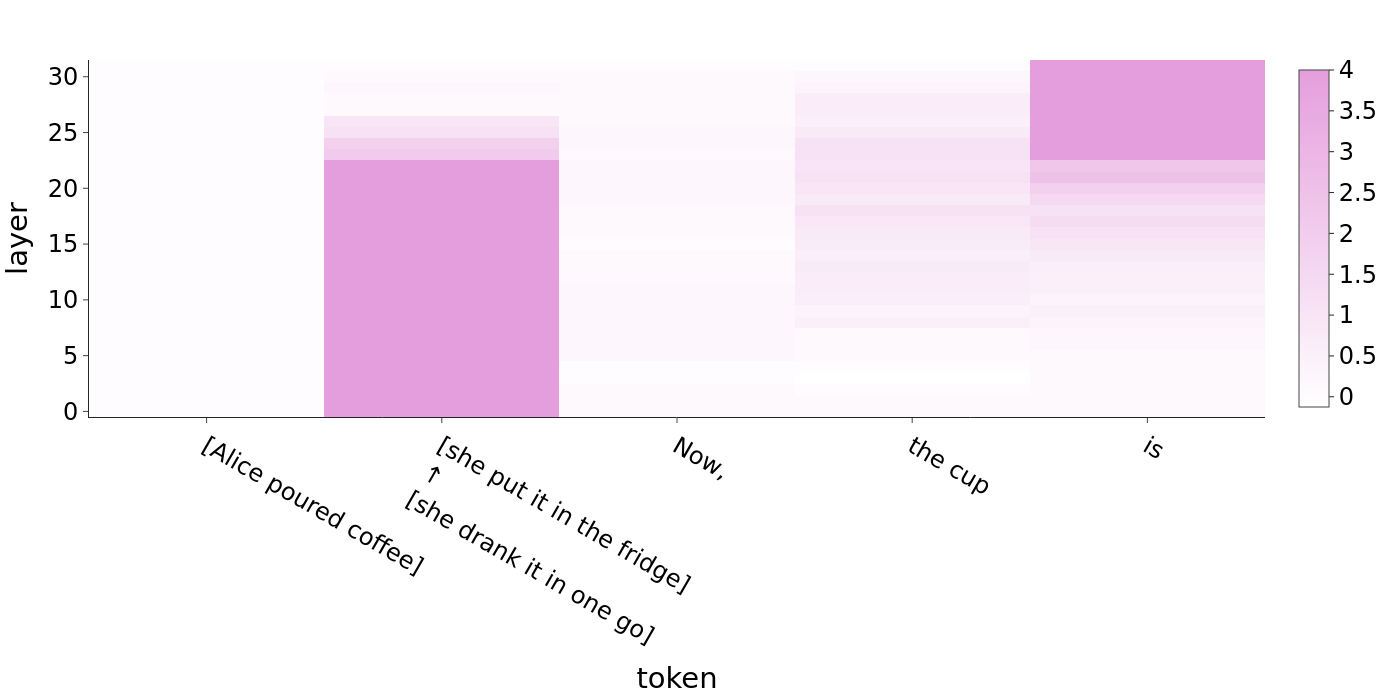

In [48]:
x = [
    "[Alice poured coffee]",
    "[she put it in the fridge]<br>↑<br>[she drank it in one go]",
    "Now,",
    "the cup",
    "is"
]

# visualize our results!
fig = px.imshow(
    causal_effects,
    zmax=4,
    x=x,
    y=list(range(model.config.num_hidden_layers)),
    template='simple_white',
    color_continuous_scale=[[0, '#FFFFFF'], [1, "#E59EDD"]]
)

fig.update_layout(
    xaxis_title='token',
    yaxis_title='layer',
    yaxis=dict(autorange='min'),
    font=dict(
        family="Arial, sans-serif",
        size=24,  # Global font size
        color="black"
    ),
    height=700,
    width=1400
)

fig.show()

Let's interpret this result!<br>
We observe the state of the cup (whether it is cold or empty) is represented at the tokens "the cup"!

In general, language models tend to aggregate contextual information at certain tokens (see [Li, Guo & Andreas, 2025](https://arxiv.org/abs/2503.02854), for example).

### ✏ **Exercise 3**

For this exercise, we will use workbench (https://workbench-git-v2-ndif.vercel.app/).

Let's consider the following two scenarios.

(1)
> Alice returned the book to Sarah because she finished it.<br><br>
> Question: Who does “she” refer to?<br><br>
> Answer:

(2)
> Alice returned the book to Sarah because she needed it.<br><br>
> Question: Who does “she” refer to?<br><br>
> Answer:

In (1), the one finishing the book is most likely Alice, so the answer should be Alice.<br>
In contrast, in (2), the one needing the book is most likely Sarah, so the answer should be Sarah.

This is an example of a Winograd Schema, a task that requires a situation model, a schema based on world knowledge.<br>
In the example above, in order to perform the pronoun disambiguation (i.e., knowing which noun the pronoun refers to), the model has to know different reasons a person may return a book.

Let's use workbench to see how the model solves this.

To make sure the model is performant enough to solve this task, use **llama-3.3-70B-Instruct**.

[1] Swap the last token to make sure the last token influences the model prediction.

[2] Swap words in the middle of the sentence to see how that changes the model prediction. Which token seems to have a large effect? (Hint: it may take too much time to explore all possible token positions. At which token position would the model aggregate information?)


[3] Change the names of the source sentence from Alice and Sarah to Bec and Cynthia, while keeping the base sentence the same. Swap the pronouns ('she') in the 'Question.' What kind of result do you expect? Did you get what you expected?

Does the model store intermediate information at specific tokens? If so, which ones? Why do you think that the model would learn this aggregation method?

> FILL IN YOUR ANSWER HERE

## 5️⃣ Multi-source Intervention

In this section, we will use multiple source sentences to get 'compositional' effects.

Let's go back to the Eiffel Tower example.<br>
Given the base prompt "Eiffel Tower is in the country of", we now want to not only change the monument entity (Eiffel Tower => Tokyo Tower), but also change which property of the monument entity the model should answer (the country => the city).

In other words, our goal is to give the model the base prompt ("Eiffel Tower is in the country of") but steer the model to answer "Tokyo" (not "Japan" like we did in section 2️⃣).

In section 3️⃣, we observed attention output at specific layers represent the country information ("France" vs "Japan") and in the exercise, we saw the same result for the the aspect information ("country" vs "city").

If this interpretation is correct, by combining the two interventions, we should be able to overwrite the country information and the property information and make the model say "Tokyo."

In [49]:
# we now use two source prompts
base_prompt = "Eiffel Tower is in the country of"

with model.generate(base_prompt, max_new_tokens=1) as tracer:
  output = model.generator.output.save()

clear_output()

print(model.tokenizer.decode(output)[0])

Eiffel Tower is in the country of France


In [50]:
source_prompt_1 = "Tokyo Tower is in the country of"

with model.generate(source_prompt_1, max_new_tokens=1) as tracer:
  output = model.generator.output.save()

clear_output()

print(model.tokenizer.decode(output)[0])

Tokyo Tower is in the country of Japan


In [51]:
source_prompt_2 = "Eiffel Tower is in the city of"

with model.generate(source_prompt_2, max_new_tokens=1) as tracer:
  output = model.generator.output.save()

clear_output()

print(model.tokenizer.decode(output)[0])

Eiffel Tower is in the city of Paris


In [52]:
base_output = model.tokenizer(" France")["input_ids"][0] # includes a space
source_output_1 = model.tokenizer(" Japan")["input_ids"][0] # includes a space
source_output_2 = model.tokenizer(" Paris")["input_ids"][0] # includes a space
source_output = model.tokenizer(" Tokyo")["input_ids"][0] # includes a space

In [53]:
source_hidden_states_1 = []
with torch.no_grad():
    with model.trace(source_prompt_1):
        # index into attention head outputs
        source_hidden_states_1.append([
            layer.self_attn.o_proj.input.save()
            for layer in model.model.layers
        ])
source_hidden_states_1 = source_hidden_states_1[0]

In [54]:
source_hidden_states_2 = []
with torch.no_grad():
    with model.trace(source_prompt_2):
        # index into attention head outputs
        source_hidden_states_2.append([
            layer.self_attn.o_proj.input.save()
            for layer in model.model.layers
        ])
source_hidden_states_2 = source_hidden_states_2[0]

Let's run causal mediation analysis!

In [55]:
# intervene and collect intervention results
import pandas as pd

token_idx = -1
logprobs = []
for interv_type in ['no_intervention','source_country','source_property','combined']:
    if interv_type=='no_intervention':
        interv_country, interv_property = False, False
    if interv_type=='source_country':
        interv_country, interv_property = True, False
    if interv_type=='source_property':
        interv_country, interv_property = False, True
    if interv_type=='combined':
        interv_country, interv_property = True, True
    with torch.no_grad():
        with model.trace(base_prompt) as tracer:
            # change the value of the base activation to the source value
            for layer_idx in range(model.config.num_hidden_layers):
                if layer_idx in [24,25,26,27] and interv_country: # intervene at layer 24-27 for the country information
                    model.model.layers[layer_idx].self_attn.o_proj.input[:, token_idx, :] = \
                        source_hidden_states_1[layer_idx][:, token_idx, :]
                if layer_idx in [0,1,2,3,4,5] and interv_property: # intervene at layer 0-5 for the property information
                    model.model.layers[layer_idx].self_attn.o_proj.input[:, token_idx, :] = \
                        source_hidden_states_2[layer_idx][:, token_idx, :]

            # get intervened output
            intervened_logits = model.output.logits[:, -1, :]
            intervened_logprobs = intervened_logits.log_softmax(dim=-1).save()
    logprobs.extend([[interv_type, 'France', intervened_logprobs[0,base_output].item()],
                     [interv_type, 'Japan', intervened_logprobs[0,source_output_1].item()],
                     [interv_type, 'Paris', intervened_logprobs[0,source_output_2].item()],
                     [interv_type, 'Tokyo', intervened_logprobs[0,source_output].item()]])
df = pd.DataFrame(logprobs,columns=['intervention','next token','log probability'])

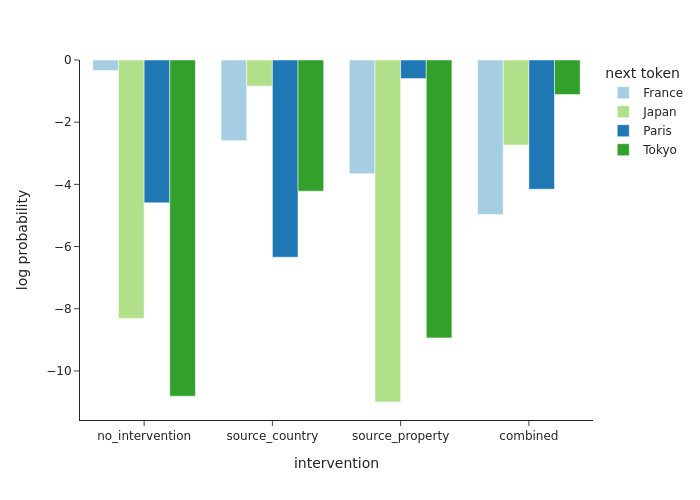

In [56]:
fig = px.bar(
    df, 
    x="intervention", 
    y="log probability",
    color="next token",
    color_discrete_sequence=['#a6cee3','#b2df8a','#1f78b4','#33a02c'],
    barmode="group",
    template="simple_white"
)

fig.show()

Let's unpack this result!
 - With no intervention, the most likely next token is "France", as expected.<br>
 - By intervening on layers 24-27 using representations from the "Tokyo Tower" prompt change the model prediction to "Japan." This is replication of section 3️⃣.<br>
 - By intervening on layers 0-5 using representations from the "city" prompt change the model prediction to "Paris." This is replication of exercise 2.<br>
 - Finally, by combining the two interventions, we manage to make the model predict "Tokyo"!

Why is this important?<br>
An alternative interpretation of the results from section 3️⃣ and exercise 2 is that these interventions are item-specific; they encode "Japan" information (not country information) or "Paris" information (not property information).<br>
Under this hypothesis, these interventions can force the model to predict "Japan" or "Paris", whatever the base prompt may be.

Our result here rejects this interpretation.<br>
Since "Tokyo" does not appear in either source prompts, the reason the model predicted "Tokyo" cannot be bacause we patched a "Tokyo" representation; instead this is a "compositional" effect emerging from two separate interventions!

## 🧠 Takeaways

In this lecture, we learned:
- Causal Mediation Analysis performs interchange intervention on each model component to measure its effect model output, which allows us to track context information across tokens and layers.
- Intervening on sub-layer components (such as attention outputs) reveals which attention heads are involved.
- Models sometimes store context information in intermediate token positions to track states in a long sequence.
- Combining multiple interventions can have compositional effects.

## 📖 References

Code is based on the NNsight tutorial ([Causal Mediation II](https://nnsight.net/tutorials/tutorials/causal_mediation_analysis/causal_mediation_analysis_ii/)).

Causal Mediation Analysis on different phenomena:
- gender bias: [Vig et al., 2020](https://arxiv.org/abs/2004.12265).
- subject verb agreement [Finlayson et al., 2021](https://arxiv.org/abs/2106.06087).
- indirect object identification: [Wang et al., 2022](https://arxiv.org/abs/2211.00593).
- situation model: [Yamakoshi et al., 2023](https://arxiv.org/abs/2306.03882).
- filler gap dependency: [Boguraev, Potts &  Mahowald, 2025](https://arxiv.org/abs/2505.16002).